In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

In [19]:
data = pd.read_csv("dataset2.csv")

In [20]:
print(data.columns.tolist())

['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description']


# Data Preprocessing , Feature Engineering

In [21]:
data['publish_time'] = pd.to_datetime(data['publish_time'], errors='coerce')
data['publish_hour'] = data['publish_time'].dt.hour.fillna(12).astype(int)
data['publish_weekday'] = data['publish_time'].dt.dayofweek.fillna(0).astype(int)
data['publish_month'] = data['publish_time'].dt.month.fillna(1).astype(int)

data['tag_count'] = data['tags'].astype(str).str.count('|') + 1
data['tag_length'] = data['tags'].astype(str).str.len()

data['title_length'] = data['title'].astype(str).str.len()
data['description_length'] = data['description'].astype(str).str.len()

data['category_encoded'] = data['category_id'].astype('category').cat.codes

data['comments_disabled'] = data['comments_disabled'].astype(int)
data['ratings_disabled'] = data['ratings_disabled'].astype(int)
data['video_error_or_removed'] = data['video_error_or_removed'].astype(int)

In [22]:
threshold = data['views'].quantile(0.7)
data['high_views'] = (data['views'] >= threshold).astype(int)


# Feature Selection

In [23]:
features = [
    'likes', 'dislikes', 'comment_count',
    'tag_count', 'tag_length',
    'title_length', 'description_length',
    'category_encoded',
    'comments_disabled', 'ratings_disabled', 'video_error_or_removed',
    'publish_hour', 'publish_weekday', 'publish_month'
]

x = data[features].fillna(0)
y = data['high_views']

# Train-Test Split

In [24]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


# Model Architecture

In [25]:

model = keras.Sequential([

    layers.Input(shape=(x_train_scaled.shape[1],)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(1, activation='sigmoid')
])

# Model Compilation






# Training Callbacks

In [26]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=0.00001,
    verbose=1
)

In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,025 (191.50 KB)

 Trainable params: 48,065 (187.75 KB)

 Non-trainable params: 960 (3.75 KB)

# Model Training

In [28]:
history = model.fit(
    x_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)



y_pred_prob = model.predict(x_test_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int)

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5940 - loss: 0.7596 - precision: 0.3863 - recall: 0.6003 - val_accuracy: 0.7510 - val_loss: 0.5553 - val_precision: 0.9796 - val_recall: 0.1600 - learning_rate: 0.0010
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7445 - loss: 0.5357 - precision: 0.5620 - recall: 0.5903 - val_accuracy: 0.7746 - val_loss: 0.4879 - val_precision: 0.9863 - val_recall: 0.2400 - learning_rate: 0.0010
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8005 - loss: 0.4609 - precision: 0.7274 - recall: 0.5822 - val_accuracy: 0.8268 - val_loss: 0.4078 - val_precision: 0.9921 - val_recall: 0.4167 - learning_rate: 0.0010
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8454 - loss: 0.3844 - precision: 0.7853 - recall: 0.6578 - val_accuracy: 0.8543 - val_loss: 0.3515 - val_precision: 0.9691 - val_recall: 0.5233 - learning_rate: 0.0010
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.846

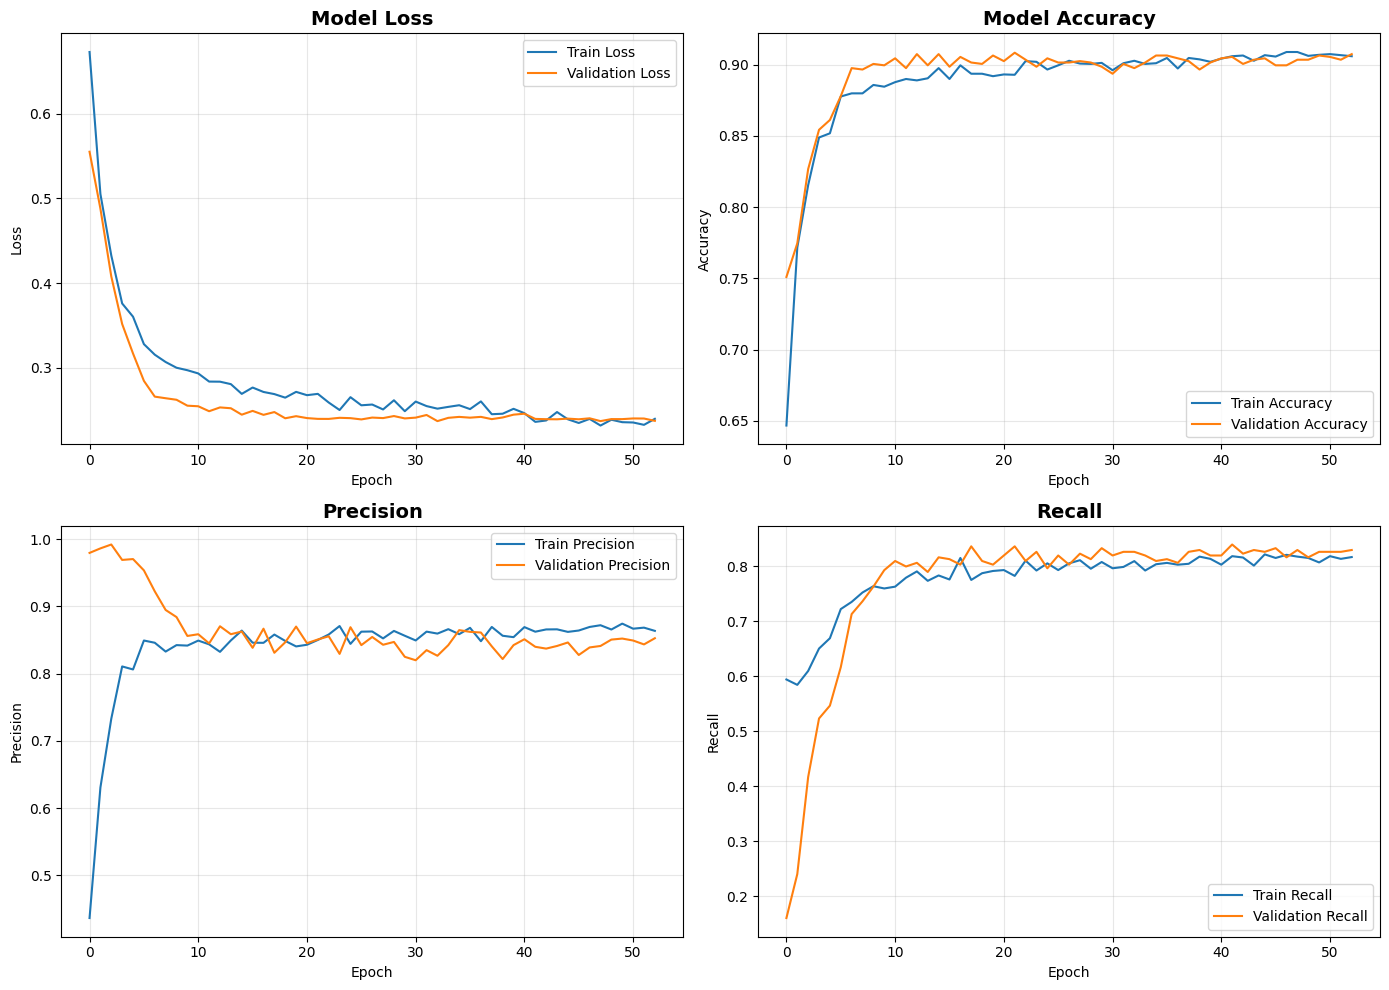

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

if 'precision' in history.history:
    axes[1, 0].plot(history.history['precision'], label='Train Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title('Precision', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
if 'recall' in history.history:
    axes[1, 1].plot(history.history['recall'], label='Train Recall')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axes[1, 1].set_title('Recall', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
weights = model.layers[0].get_weights()[0]
importance = np.abs(weights).mean(axis=1)

feat_imp = pd.DataFrame({
    'feature': features,
    'importance': importance
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("TOP 10 FEATURES (based on neural network weights)")
print("="*50)
print(feat_imp.head(10))



TOP 10 FEATURES (based on neural network weights)
                   feature  importance
0                    likes    0.157110
1                 dislikes    0.143343
2            comment_count    0.097647
3                tag_count    0.075726
4               tag_length    0.074158
9         ratings_disabled    0.070883
7         category_encoded    0.069924
10  video_error_or_removed    0.069252
11            publish_hour    0.067835
13           publish_month    0.065951


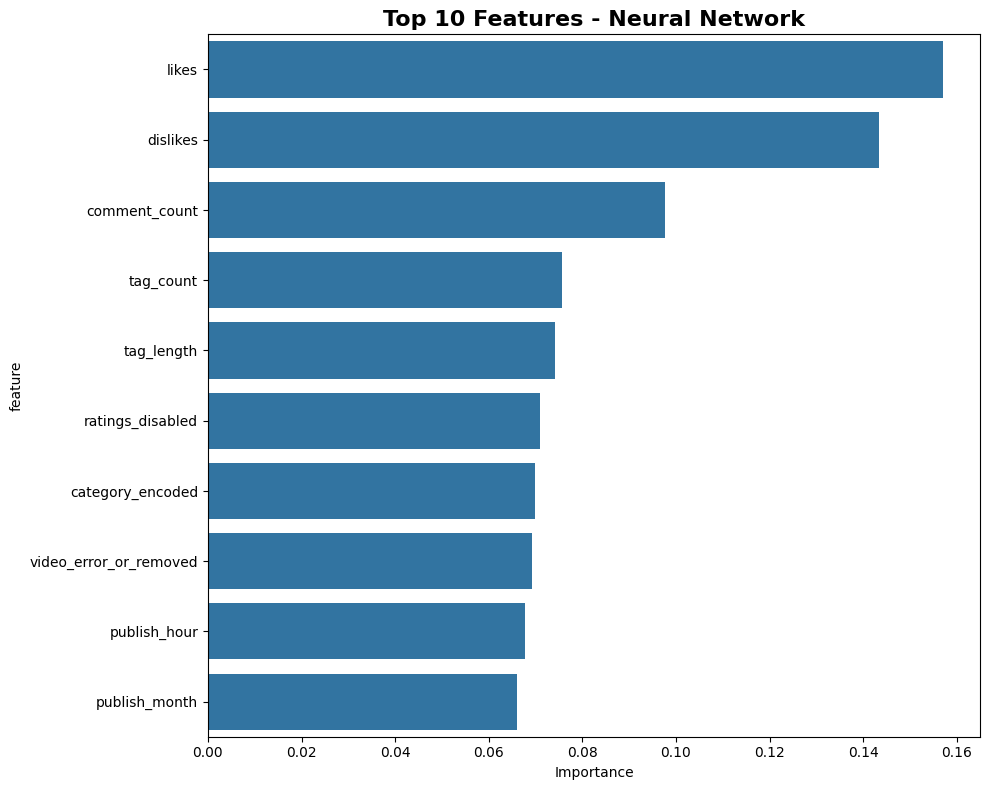

In [31]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=feat_imp.head(10), y='feature', x='importance', ax=ax)
ax.set_title('Top 10 Features - Neural Network', fontsize=16, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [32]:
train_pred = (model.predict(x_train_scaled) >= 0.5).astype(int)
test_pred = (model.predict(x_test_scaled) >= 0.5).astype(int)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Gap:", train_acc - test_acc)

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step
Train Accuracy: 0.9110236220472441
Test Accuracy: 0.9000786782061369
Gap: 0.010944943841107224
